In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [49]:
df=pd.read_csv('sales_data_with_discounts.csv')
df
# df['Avg Price'].value_counts()

df1 = df.select_dtypes(include=['int', 'float'])
df1


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...
445,2,1300,2600,15.475687,402.367873,2197.632127
446,6,2600,15600,17.057027,2660.896242,12939.103758
447,2,1600,3200,18.965550,606.897606,2593.102394
448,3,1900,5700,16.793014,957.201826,4742.798174


In [50]:
df1.mean(numeric_only=True)
array_stats = pd.DataFrame({'Mean:':df1.mean(),
              'Median:':df1.median(),
              'Mode:':df1.mode().iloc[0],
              'Standard Deviation:':df1.std()})
array_stats
# df2 = pd.DataFrame(array_stats)


,Mean:,Median:,Mode:,Standard Deviation:
Volume,5.066667,4.000000,3.000000,4.231602
Avg Price,10453.433333,1450.000000,400.000000,18079.904840
Total Sales Value,33812.835556,5700.000000,24300.000000,50535.074173
Discount Rate (%),15.155242,16.577766,5.007822,4.220602
Discount Amount,3346.499424,988.933733,69.177942,4509.902963
Net Sales Value,30466.336131,4677.788059,326.974801,46358.656624


**Mean: ** Mean is the average of the column in a dataset. It is the sum of all values of the column divided by the number of values.

**Median: ** The middle value of each column in a Dataset. It divides the dataset into two equal halves. If you have two numbers once the column values are divided into halves, then it is average of those two values.It is useful when there are outliers or skewed data.

**Mode:** The most repeating values in the dataset. There can be more than one mode then it called Multi Mode. It is useful to identify common or popular values.

**Standard Deviation: ** A measure of how spread out the data is around the mean. A low standard deviation means values are close to the mean, while a high one indicates more variability.

In [51]:
# data_columns = df.columns
# print(data_columns)

num_cat = [i for i in df.columns if df[i].dtypes!='O']

print(num_cat)

['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


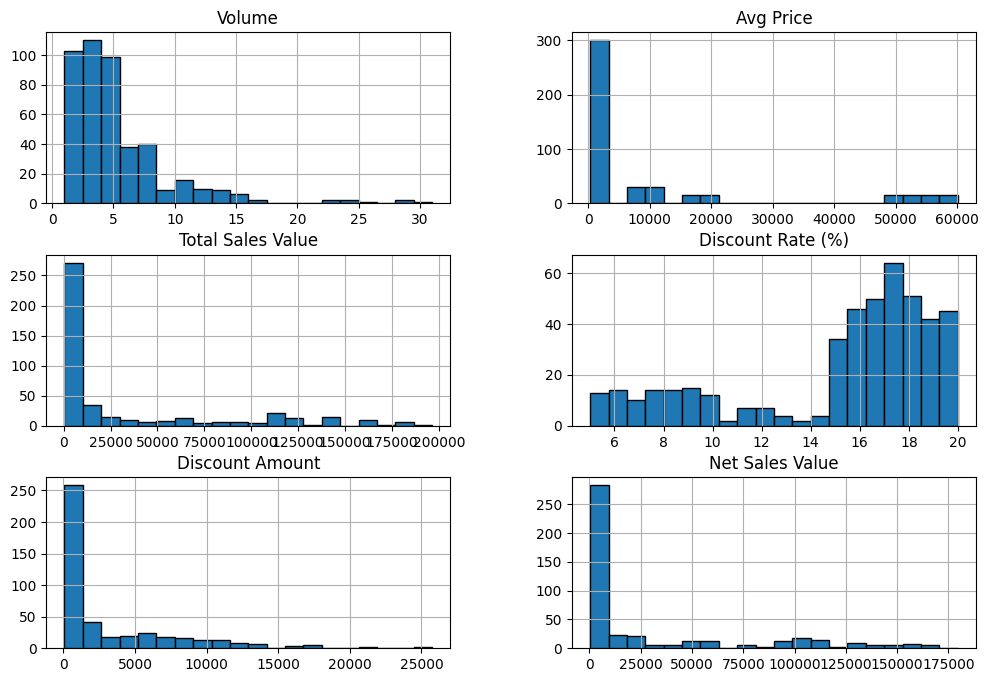

In [53]:
num_cat = df.select_dtypes(include='number')
# print(num_cat)
num_cat.hist(bins=20, figsize=(12, 8), edgecolor='black')
plt.show()

1. If the data is equally distributed across and if we draw the distribution curve along the edges of the histogram graphs then it is called Normal Distribution and it looks like Bell curve. it is easy to find the there is skewnewss or not. Here Mean = Median
2. If the data is less at right side then it is righ skewed (called Positive Skew) and there are outliers at right side. In this case Mean > Median. For example from above charts, Volume, Avg Price, Total Sales values, Discount Amount and Net Sales Value. Volumn Mean > Median so it is right Skewed.
3. Similarly if the data is less at Left side it is Left skewed (called Negative Skew) and the more outliers at Left side. In this case Mean < Median. Discount Rate % Mean < Median so even in the graph the data is less at left side.

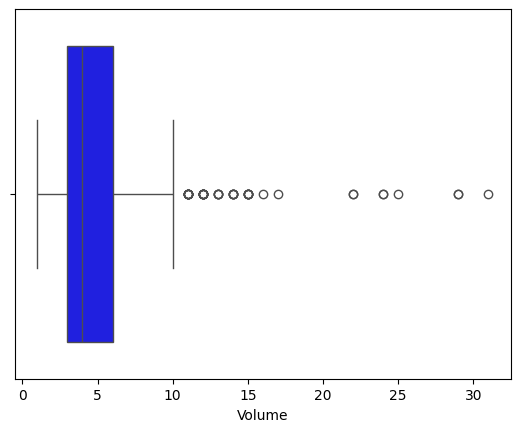

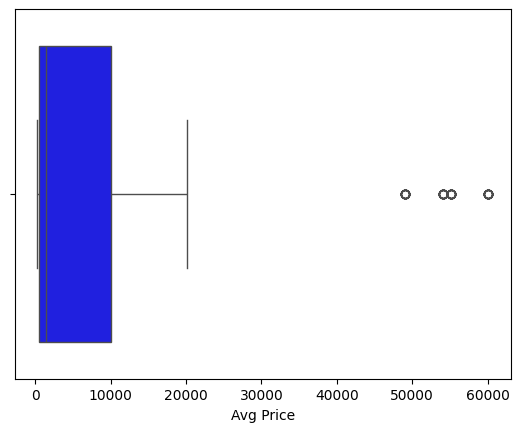

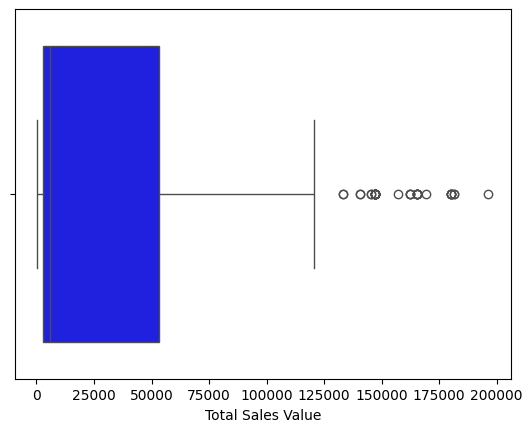

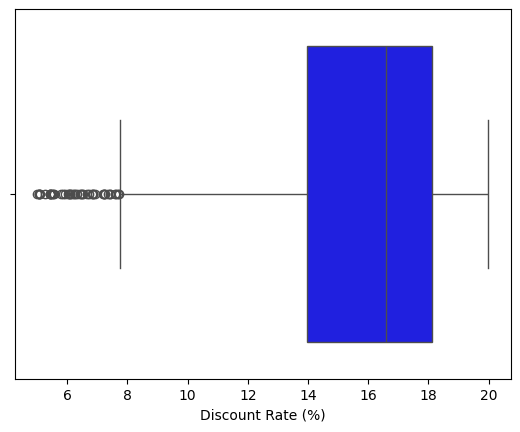

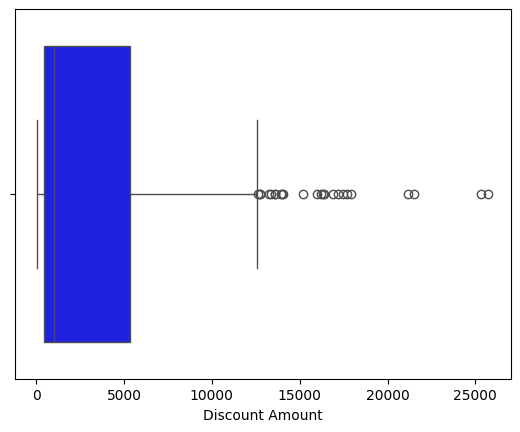

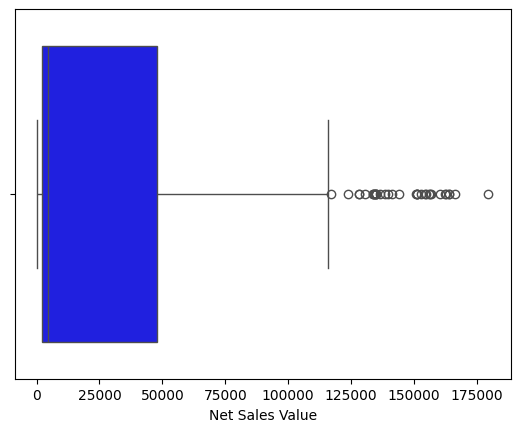

In [54]:
num_cat = df.select_dtypes(include='number')
# print(num_cat)

for i in num_cat:
  sns.boxplot(data=df,x=i,color='blue')
  plt.show()

From above Histogram graphs we identified that Volume, Avg Price, Total Sales values, Discount Amount and Net Sales Value are Right skewed and the outliers are at Right side. The same is visible in the above Box plot graphs with small circles. the box show the Interquartile Range where most of the data is present.

Discount Rate(%) is Left Skewed(Negative) and the Outliers are at Left side, the same is represented in the box Plot as well.

In [55]:
for col in num_cat.columns:
    Q1 = num_cat[col].quantile(0.25)
    Q3 = num_cat[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = num_cat[(num_cat[col] < Q1 - 1.5 * IQR) | (num_cat[col] > Q3 + 1.5 * IQR)]
    print(f"{col} — IQR: {IQR}, Outliers: {len(outliers)} rows")

Volume — IQR: 3.0, Outliers: 44 rows
Avg Price — IQR: 9635.0, Outliers: 60 rows
Total Sales Value — IQR: 50500.0, Outliers: 36 rows
Discount Rate (%) — IQR: 4.149655934050962, Outliers: 45 rows
Discount Amount — IQR: 4856.03612280112, Outliers: 24 rows
Net Sales Value — IQR: 45645.70420627015, Outliers: 35 rows


Index(['Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


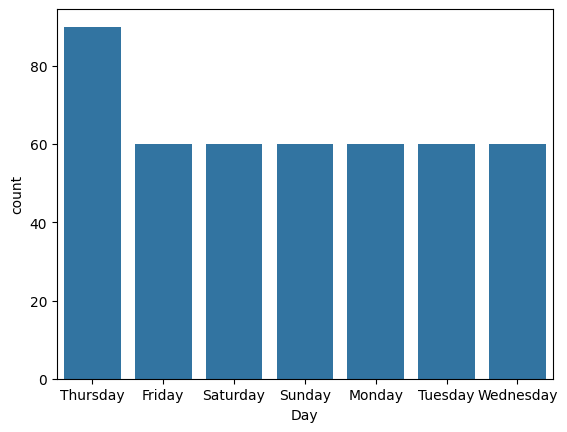

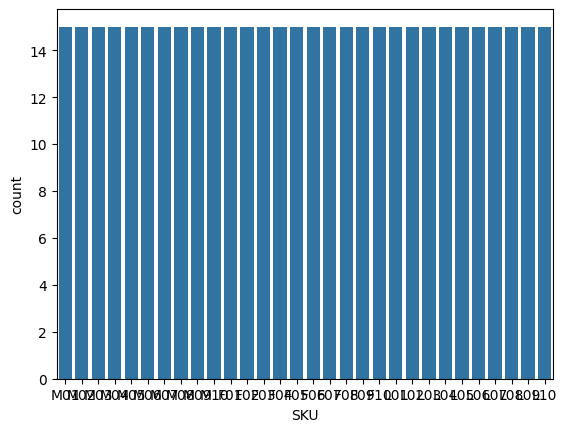

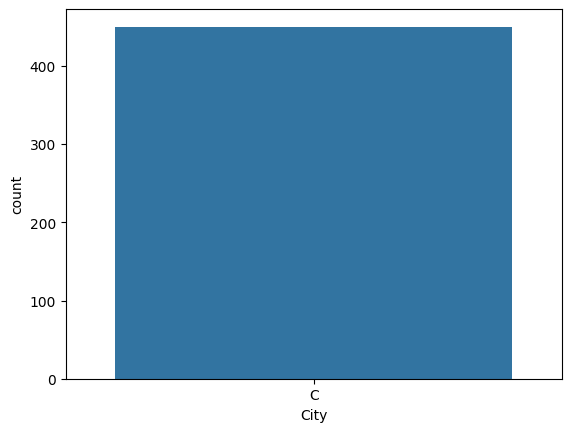

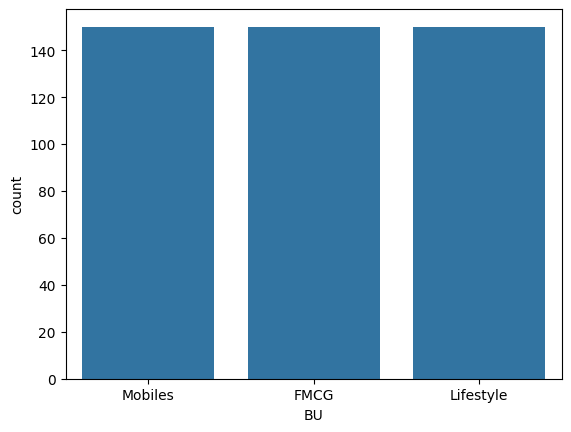

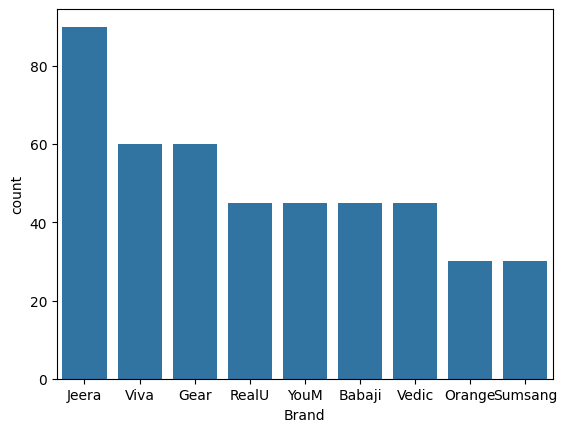

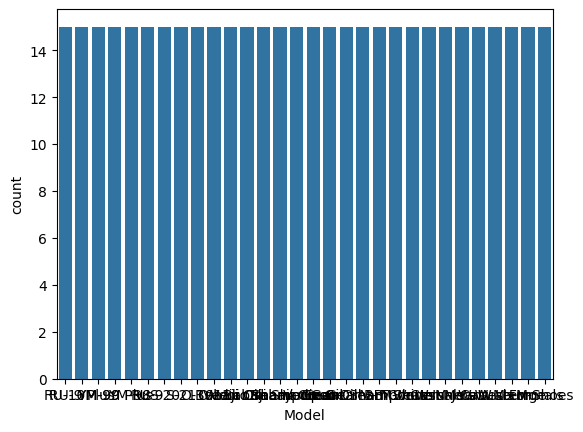

In [56]:
cat_col = df.select_dtypes(include='object').columns
cat_col=cat_col.drop('Date')
print(cat_col)
for col in cat_col:
  sns.countplot(data=df, x=col, order=df[col].value_counts().index)
  plt.show()

From Brand Column, Jeera is is very tall so it is most frequent/repeating data in that column. Viva and Gear are same frequent so they are in the same Height.YouM, RealU,Babaji and Vedic are next most frequent data and lastly Orange and Sumsang are in same occuring data.
The BU column has all three values Mobiles, FMCG and LifeStyle are in the same range so equal frequency.
The SKU column has all data values are in the same range.
In Column Day, Only Thursday is most frequent value.

In [57]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

df[['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']] = \
std_scaler.fit_transform(num_cat[['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']])
df

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,2.350029,Mobiles,RealU,RU-10,0.091173,2.925721,-0.830289,3.952816,2.804756
1,01-04-2021,Thursday,M02,C,1.167129,Mobiles,RealU,RU-9 Plus,-0.019570,1.330995,-0.852661,1.849014,1.271026
2,01-04-2021,Thursday,M03,C,0.457388,Mobiles,YouM,YM-99,0.312659,1.562775,-1.351631,1.622995,1.545675
3,01-04-2021,Thursday,M04,C,0.220808,Mobiles,YouM,YM-99 Plus,0.534146,1.719276,-1.949723,1.113807,1.765810
4,01-04-2021,Thursday,M05,C,-0.488932,Mobiles,YouM,YM-98,-0.130313,-0.188452,0.673739,0.227852,-0.227595
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,-0.725512,Lifestyle,Jeera,M-Casuals,-0.506840,-0.618334,0.076009,-0.653541,-0.610461
446,15-04-2021,Thursday,L07,C,0.220808,Lifestyle,Viva,W-Western,-0.434857,-0.360801,0.451097,-0.152191,-0.378500
447,15-04-2021,Thursday,L08,C,-0.725512,Lifestyle,Viva,W-Lounge,-0.490229,-0.606448,0.903793,-0.608140,-0.601921
448,15-04-2021,Thursday,L09,C,-0.488932,Lifestyle,Jeera,M-Formals,-0.473617,-0.556923,0.388474,-0.530379,-0.555499


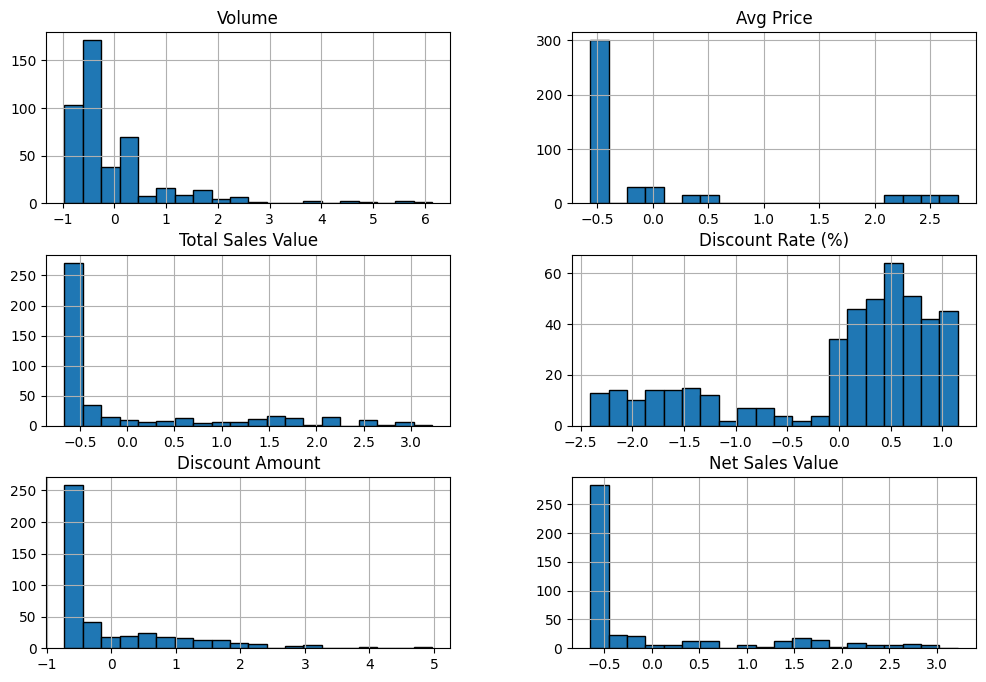

In [28]:
num_cat.hist(bins=20, figsize=(12, 8), edgecolor='black')
plt.show()

In [58]:
### DO NOT Execute as this change the Dataset and next steps wont work. this is only for Informational purpose only to show Get Dummies

df.columns
cat_col = df.select_dtypes(include='object').columns
cat_col=cat_col.drop('Date')
print(cat_col)

data = pd.get_dummies(df['BU'])

data
### DO NOT Execute as this may disturb the Dataset this is only for Informational purpose only.

Index(['Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


,FMCG,Lifestyle,Mobiles
0,False,False,True
1,False,False,True
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
445,False,True,False
446,False,True,False
447,False,True,False
448,False,True,False


In [59]:
from sklearn.preprocessing import OneHotEncoder
one_hot = OneHotEncoder()

df['BU'].unique()
df1=pd.DataFrame(one_hot.fit_transform(df[['BU']]).toarray(),columns=['Mobiles', 'FMCG', 'Lifestyle'])

# df1=pd.DataFrame(one_hot.fit_transform(cat_col).toarray(),columns=['1','0'])
df1


,Mobiles,FMCG,Lifestyle
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
445,0.0,1.0,0.0
446,0.0,1.0,0.0
447,0.0,1.0,0.0
448,0.0,1.0,0.0


In [60]:
df=df.join(df1)
df.drop(columns=['BU'],inplace=True)
df


,Date,Day,SKU,City,Volume,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Mobiles,FMCG,Lifestyle
0,01-04-2021,Thursday,M01,C,2.350029,RealU,RU-10,0.091173,2.925721,-0.830289,3.952816,2.804756,0.0,0.0,1.0
1,01-04-2021,Thursday,M02,C,1.167129,RealU,RU-9 Plus,-0.019570,1.330995,-0.852661,1.849014,1.271026,0.0,0.0,1.0
2,01-04-2021,Thursday,M03,C,0.457388,YouM,YM-99,0.312659,1.562775,-1.351631,1.622995,1.545675,0.0,0.0,1.0
3,01-04-2021,Thursday,M04,C,0.220808,YouM,YM-99 Plus,0.534146,1.719276,-1.949723,1.113807,1.765810,0.0,0.0,1.0
4,01-04-2021,Thursday,M05,C,-0.488932,YouM,YM-98,-0.130313,-0.188452,0.673739,0.227852,-0.227595,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,-0.725512,Jeera,M-Casuals,-0.506840,-0.618334,0.076009,-0.653541,-0.610461,0.0,1.0,0.0
446,15-04-2021,Thursday,L07,C,0.220808,Viva,W-Western,-0.434857,-0.360801,0.451097,-0.152191,-0.378500,0.0,1.0,0.0
447,15-04-2021,Thursday,L08,C,-0.725512,Viva,W-Lounge,-0.490229,-0.606448,0.903793,-0.608140,-0.601921,0.0,1.0,0.0
448,15-04-2021,Thursday,L09,C,-0.488932,Jeera,M-Formals,-0.473617,-0.556923,0.388474,-0.530379,-0.555499,0.0,1.0,0.0


In [42]:
df['Brand'].unique()

array(['RealU', 'YouM', 'Sumsang', 'Orange', 'Babaji', 'Vedic', 'Gear',
       'Jeera', 'Viva'], dtype=object)

In [61]:
df1=pd.DataFrame(one_hot.fit_transform(df[['Brand']]).toarray(),columns=['RealU', 'YouM', 'Sumsang', 'Orange', 'Babaji', 'Vedic', 'Gear',
       'Jeera', 'Viva'])
df1
df.drop(columns=['Brand'],inplace=True)
df=df.join(df1)


In [62]:
df

,Date,Day,SKU,City,Volume,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,...,Lifestyle,RealU,YouM,Sumsang,Orange,Babaji,Vedic,Gear,Jeera,Viva
0,01-04-2021,Thursday,M01,C,2.350029,RU-10,0.091173,2.925721,-0.830289,3.952816,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,01-04-2021,Thursday,M02,C,1.167129,RU-9 Plus,-0.019570,1.330995,-0.852661,1.849014,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,01-04-2021,Thursday,M03,C,0.457388,YM-99,0.312659,1.562775,-1.351631,1.622995,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,01-04-2021,Thursday,M04,C,0.220808,YM-99 Plus,0.534146,1.719276,-1.949723,1.113807,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,01-04-2021,Thursday,M05,C,-0.488932,YM-98,-0.130313,-0.188452,0.673739,0.227852,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,-0.725512,M-Casuals,-0.506840,-0.618334,0.076009,-0.653541,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
446,15-04-2021,Thursday,L07,C,0.220808,W-Western,-0.434857,-0.360801,0.451097,-0.152191,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
447,15-04-2021,Thursday,L08,C,-0.725512,W-Lounge,-0.490229,-0.606448,0.903793,-0.608140,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
448,15-04-2021,Thursday,L09,C,-0.488932,M-Formals,-0.473617,-0.556923,0.388474,-0.530379,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
df['Model'].unique()

array(['RU-10', 'RU-9 Plus', 'YM-99', 'YM-99 Plus', 'YM-98 ', 'RU-9',
       'S-20', 'S-21', 'O-10', 'O-11', 'Babaji Oil ', 'Vedic Cream',
       'Vedic Shampoo', 'Babaji Shampoo', 'Babaji Cream', 'Vedic Oil',
       'Gear Oil', 'Gear Cream', 'Gear Shampoo', 'Gear BB Cream',
       'M- T Shirts', 'M- Inners', 'W-Casuals', 'W-Inners', 'M-Jeans',
       'M-Casuals', 'W-Western', 'W-Lounge', 'M-Formals', 'M-Shoes'],
      dtype=object)

In [66]:
df['SKU'].unique()

array(['M01', 'M02', 'M03', 'M04', 'M05', 'M06', 'M07', 'M08', 'M09',
       'M10', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08',
       'F09', 'F10', 'L01', 'L02', 'L03', 'L04', 'L05', 'L06', 'L07',
       'L08', 'L09', 'L10'], dtype=object)

As there many Model and SKU varieties, not applying the one Hot Encoder as the dataset will grow. we need to repeat the same step 61 for these columns as well.
